## DATA LOADING

In [3]:
import pandas as pd #for structured data, like tables or spreadsheets
#A DataFrame is the core data structure in pandas.
#Think of it as a table with rows and columns, much like a spreadsheet. 

In [16]:
# Load SMS dataset
sms_df = pd.read_csv('../data/spam.csv', encoding='latin-1')
sms_df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [19]:
#When you pass a list of column names within double square brackets to a DataFrame, 
#pandas returns a new DataFrame containing only those specified columns.
sms_df = sms_df[['v1', 'v2']]
sms_df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [20]:
#Rename the columns:
sms_df.columns = ['label', 'text']
sms_df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [25]:
#Check shape
sms_df.shape #Get the dimensions (number of rows and columns) of the DataFrame.

(5572, 2)

In [27]:
#Get a concise summary of the DataFrame
sms_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [28]:
# Count the occurrences of each unique value in the 'label' column
sms_df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [29]:
# Check for duplicate rows in the entire DataFrame and count the number of duplicates.
sms_df.duplicated().sum()

np.int64(403)

In [30]:
# Check for missing values (NaN - Not a Number) in each column and count the total missing values per column.
sms_df.isnull().sum()

label    0
text     0
dtype: int64

In [31]:
# Remove duplicate rows from the DataFrame, keeping only the first occurrence.
sms_df = sms_df.drop_duplicates(keep = 'first')

In [32]:
sms_df.duplicated().sum()

np.int64(0)

In [33]:
# Remove rows containing any missing values (NaN) from the DataFrame.
sms_df = sms_df.dropna()

In [34]:
sms_df.isnull().sum()

label    0
text     0
dtype: int64

## DATA CLEANING & PREPROCESSING

In [36]:
import string  # Provides a collection of string constants (like punctuation, !"#$%&'()*+,...).
import re      # Provides regular expression operations for pattern matching.
import nltk    # The Natural Language Toolkit, a powerful library for working with human language data.
from nltk.corpus import stopwords  # A list of common words (like 'the', 'is', 'in') that often don't carry much meaning.
nltk.download('stopwords')         # Download the 'stopwords' resource from NLTK if it hasn't been downloaded already.

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ranji\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [38]:
# Define a function called 'clean_text' that takes a text string as input and performs several cleaning operations.
def clean_text(text):
    text = text.lower() # Convert the input text to lowercase. This ensures consistency (e.g., 'Hello' and 'hello' are treated the same).
    text = re.sub(r'\d+', '', text) #r'\d+' is a special pattern that looks for one or more digits (0-9) in the text. We're telling Python to replace any digits it finds with an empty string (''), which means we're just removing them.
    text = text.translate(str.maketrans('', '', string.punctuation)) # Here, we're dealing with punctuation marks like commas, periods, exclamation points, etc. string.punctuation gives us a list of all these characters. str.maketrans('', '', string.punctuation) creates a special "translation table" that tells Python to replace each punctuation mark with nothing (effectively deleting it). This is important because punctuation usually doesn't contribute much to the meaning of the words themselves.
    text = ' '.join([word for word in text.split() if word not in stopwords.words('english')]) #This is a "list comprehension." It's a concise way to create a new list. It goes through each word in the list of words we got from text.split(). For each word, it checks if that word is not in our list of stopwords.words('english'). If it's not a stopword, it keeps that word in our new list. So, this part effectively filters out all the common, less meaningful words.
    return text

sms_df['clean_text'] = sms_df['text'].apply(clean_text)   

## EXPLORATORY DATA ANALYSIS (EDA)

Text(0.5, 1.0, 'Label distribution')

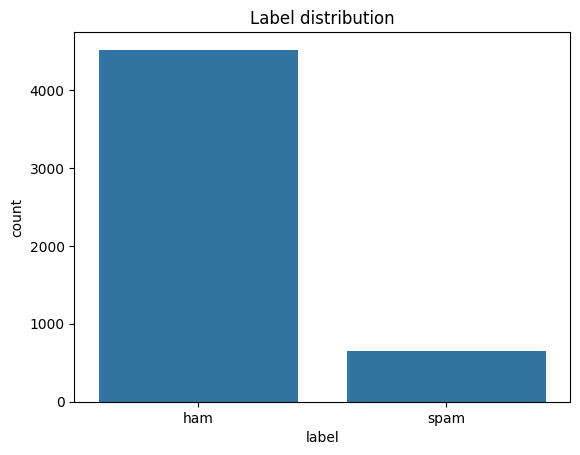

In [42]:
import matplotlib.pyplot as plt # A fundamental library for creating plots and charts in Python.
import seaborn as sns           # A higher-level visualization library built on top of Matplotlib

# Spam vs Ham
sns.countplot(data = sms_df, x = 'label')#'data' specifies the DataFrame, and 'x' specifies the column to count.
plt.title('Label distribution')

<Axes: xlabel='text_length', ylabel='Count'>

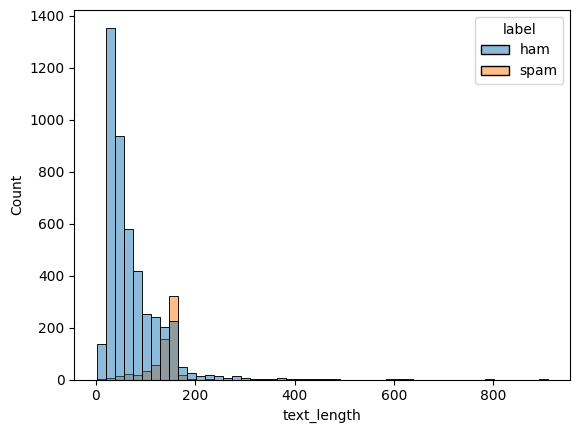

In [50]:
# Message Length
sms_df['text_length'] = sms_df['text'].apply(len)# Apply the built-in 'len' function to each text message to get its length.
sns.histplot(data = sms_df, x = 'text_length', hue = 'label', bins = 50)# 'x' specifies the column to plot (message length).
                                                                        # 'hue='label'' tells Seaborn to color the bars based on whether the message is 'spam' or 'ham'.
                                                                        # 'bins=50' divides the range of message lengths into 50 intervals (bins) to show the distribution more granularly

## FEATURE ENGINEERING

In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer
# TfidfVectorizer will convert text data into a matrix of TF-IDF features.

In [60]:
vectorizer = TfidfVectorizer(max_features = 3000)            # max_features limits the vocabulary size to the top 3000 most frequent words across all SMS messages.
x = vectorizer.fit_transform(sms_df['clean_text']).toarray() # Fit the vectorizer to the 'clean_text' column of our DF and then transform the text data into a TF-IDF matrix.
                                                             # .fit_transform() learns the vocabulary and calculates the TF-IDF scores for each word in each SMS message.
                                                             # .toarray() converts the resulting sparse matrix into a dense NumPy array.
y = sms_df['label'].map({'ham': 0, 'spam': 1}).values        # Map the 'label' column ('ham' and 'spam') to numerical values (0 and 1) and convert it to a NumPy array.

## MODEL TRAINING

In [62]:
from sklearn.model_selection import train_test_split
                        # Split the features (X) and the target variable (y) into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
                        # X: The feature matrix (TF-IDF scores of the cleaned text).
                        # y: The target variable (numerical labels: 0 for ham, 1 for spam).
                        # test_size=0.2: Specifies that 20% of the data should be used for the testing set, and the remaining 80% for the training set.
                        # random_state=42: Sets a seed for the random number generator. This ensures that the split is the same every time the code is run, which is important for reproducibility.

In [67]:
# Import the classification models we want to evaluate from scikit-learn.
from sklearn.naive_bayes import MultinomialNB # A probabilistic classifier based on Bayes' theorem, often effective for text data.
from sklearn.linear_model import LogisticRegression  # A linear model that can be used for binary classification.
from sklearn.ensemble import RandomForestClassifier  # An ensemble learning method that builds multiple decision trees.

# Import evaluation metrics from scikit-learn to assess model performance.
from sklearn.metrics import classification_report, accuracy_score

In [69]:
# Create a dictionary to store the models we want to train and evaluate.
# The keys are the names of the models, and the values are instances of the model classes.
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter = 1000),
    "Random Forest": RandomForestClassifier()
}

# Iterate through the dictionary of models.
for name, model in models.items():
    model.fit(X_train, y_train)    # Train the current model using the training data (features X_train and labels y_train).
    preds = model.predict(X_test)  # Make predictions on the testing data (features X_test).
    print(f"---{name}---")         # Print a header indicating the name of the model being evaluated.
    print(classification_report(y_test, preds))   # Print the classification report, which provides precision, recall, F1-score, and support for each class (ham and spam).

---Naive Bayes---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       889
           1       1.00      0.80      0.89       145

    accuracy                           0.97      1034
   macro avg       0.98      0.90      0.94      1034
weighted avg       0.97      0.97      0.97      1034

---Logistic Regression---
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       889
           1       0.94      0.73      0.82       145

    accuracy                           0.96      1034
   macro avg       0.95      0.86      0.90      1034
weighted avg       0.95      0.96      0.95      1034

---Random Forest---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       889
           1       0.99      0.81      0.89       145

    accuracy                           0.97      1034
   macro avg       0.98      0.90      0.94      1034
weighted a

#### Precision:
Of all the messages the model predicted as a certain class (e.g., spam), what proportion were actually of that class? (e.g., if precision for spam is 0.95, it means 95% of the messages the model called spam were indeed spam).

#### Recall:
Of all the messages that actually belong to a certain class (e.g., spam), what proportion did the model correctly identify? (e.g., if recall for spam is 0.90, it means the model correctly identified 90% of all the actual spam messages).

#### F1-score: 
The harmonic mean of precision and recall. It provides a balanced measure of the model's performance.

#### Support: 
The number of actual occurrences of the class in the test set.

## MODEL OPTIMIZATION

In [72]:
# Import the Pipeline class to chain together multiple data processing steps.

from sklearn.pipeline import Pipeline

# Import the GridSearchCV class for systematic hyperparameter tuning using cross-validation.
from sklearn.model_selection import GridSearchCV

# Create a Pipeline that first performs TF-IDF vectorization and then trains a Multinomial Naive Bayes classifier.
# The steps are defined as a list of (name, transformer/estimator) tuples.

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # Step 1: Convert text to TF-IDF features. We name this step 'tfidf'.
    ('clf', MultinomialNB())      # Step 2: Train a Multinomial Naive Bayes classifier. We name this step 'clf'.
])

# Define a dictionary of hyperparameters to tune for the Pipeline.
# The keys are in the format 'step_name__parameter_name'.
# 'tfidf__max_features': We want to try different values for the 'max_features' parameter of the TfidfVectorizer.
# 'clf__alpha': We want to try different values for the 'alpha' (smoothing parameter) of the MultinomialNB classifier.
params = {
    'tfidf__max_features': [1000, 3000],
    'clf__alpha': [0.1, 1.0]
}

# Initialize GridSearchCV to find the best combination of hyperparameters using cross-validation.
# 'pipeline': The Pipeline we want to tune.
# 'param_grid': The dictionary of hyperparameters to try.
# 'cv=5': Perform 5-fold cross-validation. This means the data will be split into 5 parts, and the model will be trained and evaluated 5 times, each time using a different part as the validation set.
# 'scoring='accuracy'': The metric we want to optimize (in this case, overall accuracy).
grid = GridSearchCV(pipeline, param_grid=params, cv=5, scoring='accuracy')

# Fit the GridSearchCV object to our training data (cleaned text and labels).
# GridSearchCV will try all combinations of the hyperparameters defined in 'params' using cross-validation to find the best ones.
grid.fit(sms_df['clean_text'], y)

# Print the best mean cross-validated score achieved across all hyperparameter combinations.
print(grid.best_score_)
# Print the best combination of hyperparameters found by GridSearchCV.
print(grid.best_params_)

0.9787185358975847
{'clf__alpha': 0.1, 'tfidf__max_features': 3000}


## SAVE FINAL MODEL

In [75]:
# Import the joblib library, which provides utilities for efficient serialization (saving) of Python objects.

import joblib

# Save the best estimator (the best performing model found by GridSearchCV) to a file.
# grid.best_estimator_ contains the trained Pipeline with the optimal hyperparameters.
# '../models/spam_model.pkl' is the file path where we want to save the model.
# The '.pkl' extension is commonly used for pickled (serialized) Python objects.

joblib.dump(grid.best_estimator_, '../models/spam_model.pkl')

['../models/spam_model.pkl']

- Imagine you've spent a lot of time teaching your dog to recognize spam, and it's finally really good at it (our GridSearchCV has done the hard work of finding the best "teaching method" - the hyperparameters). You wouldn't want to have to teach it all over again every time you want it to identify a new message, right? You'd want to "save" its learned knowledge.

- That's exactly what this code does. We're using the joblib library to save our best-performing spam detection model to a file.

### import joblib: 
We're importing the joblib library. This library is specifically designed for efficiently saving and loading Python objects, especially those that contain NumPy arrays (which our trained model does). It's often more efficient for numerical data than Python's built-in pickle module.

### joblib.dump(grid.best_estimator_, '../models/spam_model.pkl'): 
This is the line that does the saving.

### grid.best_estimator_: 
Remember how GridSearchCV tried out different hyperparameter combinations and found the one that gave us the best performance? grid.best_estimator_ holds the entire trained pipeline (the TfidfVectorizer with its learned vocabulary and the MultinomialNB model trained with the best alpha value) that achieved this best score. It's our champion spam detector!

### '../models/spam_model.pkl': 
This is the file path where we want to save this best model.

### '../models/': 
This tells Python to go up one directory from the current directory and then go into a folder named models. If this folder doesn't exist, joblib will likely create it.

### 'spam_model.pkl': 
This is the name we're giving to the file where our model will be saved. The .pkl extension is a common convention for files that contain pickled (serialized) Python objects. Think of "pickling" as converting the Python object into a format that can be easily stored in a file and then loaded back into Python later.

So, this line of code takes our best-trained spam detection pipeline and saves it to a file named spam_model.pkl in a folder named models (located one level up from our current script).

### Why is this important?

Saving the model means that in the future, whenever we want to classify new SMS messages as spam or ham, we can simply load this saved spam_model.pkl file. We won't need to re-run the entire process of loading the data, cleaning it, performing TF-IDF, training the model, and tuning hyperparameters. We can just load our pre-trained model and use its .predict() method to classify new text messages directly. This saves a lot of time and computational resources, especially for more complex models and larger datasets.

This is the final step in our model building process – making our trained model persistent so we can deploy it or use it for future predictions.

## CREATE STREAMLIT APP